In [ ]:
from pybaseball import statcast_pitcher
from pybaseball import playerid_lookup
from matplotlib.ticker import MultipleLocator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
playerid_lookup('Gausman', 'Kevin')

,name_last,name_first,key_mlbam,key_retro,key_bbref,key_fangraphs,mlb_played_first,mlb_played_last
0,gausman,kevin,592332,gausk001,gausmke01,14107,2013.0,2026.0


In [7]:
gausman = statcast_pitcher('2013-01-01', '2026-09-22', 592332)
gausman.columns.to_list()

Gathering Player Data


['pitch_type',
 'game_date',
 'release_speed',
 'release_pos_x',
 'release_pos_z',
 'player_name',
 'batter',
 'pitcher',
 'events',
 'description',
 'spin_dir',
 'spin_rate_deprecated',
 'break_angle_deprecated',
 'break_length_deprecated',
 'zone',
 'des',
 'game_type',
 'stand',
 'p_throws',
 'home_team',
 'away_team',
 'type',
 'hit_location',
 'bb_type',
 'balls',
 'strikes',
 'game_year',
 'pfx_x',
 'pfx_z',
 'plate_x',
 'plate_z',
 'on_3b',
 'on_2b',
 'on_1b',
 'outs_when_up',
 'inning',
 'inning_topbot',
 'hc_x',
 'hc_y',
 'tfs_deprecated',
 'tfs_zulu_deprecated',
 'umpire',
 'sv_id',
 'vx0',
 'vy0',
 'vz0',
 'ax',
 'ay',
 'az',
 'sz_top',
 'sz_bot',
 'hit_distance_sc',
 'launch_speed',
 'launch_angle',
 'effective_speed',
 'release_spin_rate',
 'release_extension',
 'game_pk',
 'fielder_2',
 'fielder_3',
 'fielder_4',
 'fielder_5',
 'fielder_6',
 'fielder_7',
 'fielder_8',
 'fielder_9',
 'release_pos_y',
 'estimated_ba_using_speedangle',
 'estimated_woba_using_speedangle',
 'w

In [8]:
cols = [
    'pitch_type',
    'game_date',
    'game_year',
    'release_speed',
    'release_spin_rate',
    'events'
]
gaus_clean = gausman[cols].copy()
gaus_clean.info()

<class 'pandas.DataFrame'>
Index: 36748 entries, 0 to 6694
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pitch_type         35933 non-null  str    
 1   game_date          36748 non-null  str    
 2   game_year          36748 non-null  int64  
 3   release_speed      35936 non-null  float64
 4   release_spin_rate  32593 non-null  float64
 5   events             9486 non-null   str    
dtypes: float64(2), int64(1), str(3)
memory usage: 2.5 MB


In [9]:
gaus_clean.dropna(subset=['pitch_type', 'release_speed', 'release_spin_rate'], inplace=True)
gaus_clean.info()

<class 'pandas.DataFrame'>
Index: 32590 entries, 0 to 6694
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pitch_type         32590 non-null  str    
 1   game_date          32590 non-null  str    
 2   game_year          32590 non-null  int64  
 3   release_speed      32590 non-null  float64
 4   release_spin_rate  32590 non-null  float64
 5   events             8265 non-null   str    
dtypes: float64(2), int64(1), str(3)
memory usage: 2.2 MB


In [10]:
pitch_mix = gaus_clean.groupby(['game_year', 'pitch_type']).size().unstack(fill_value=0)
pitch_mix_pct = pitch_mix.div(pitch_mix.sum(axis=1), axis=0) * 100
pitch_mix_pct.drop(['IN', 'PO', 'ST'], axis=1, inplace=True)
pitch_mix_pct.round(1)

pitch_type,CH,FF,FS,SI,SL
game_year,,,,,
2015,3.2,70.4,17.7,2.0,6.6
2016,2.0,64.0,19.9,4.6,9.4
2017,1.1,65.0,20.5,0.0,13.4
2018,3.1,58.5,24.3,0.0,14.1
2019,3.4,57.2,37.6,0.0,1.8
2020,14.4,51.4,27.5,0.0,6.7
2021,5.6,52.9,34.9,0.2,6.5
2022,1.3,48.7,36.0,0.0,14.1
2023,0.1,51.1,37.8,0.2,10.1


In [11]:
avg_pitch_speeds = gaus_clean.groupby(['game_year', 'pitch_type'])['release_speed'].mean().unstack(fill_value=0)
avg_pitch_speeds.drop(['IN', 'PO', 'ST'], axis=1, inplace=True)
avg_pitch_speeds.round(1)

pitch_type,CH,FF,FS,SI,SL
game_year,,,,,
2015,85.8,95.9,85.5,94.3,80.0
2016,85.0,95.3,85.1,94.8,80.0
2017,85.7,94.9,85.0,90.4,82.7
2018,82.1,93.6,82.7,0.0,81.5
2019,82.6,93.9,83.5,0.0,82.5
2020,84.3,95.1,84.1,0.0,81.9
2021,83.8,94.6,83.7,94.7,82.1
2022,84.5,95.0,85.3,0.0,84.4
2023,82.5,94.7,86.3,92.6,84.0


In [12]:
avg_spin_rate = gaus_clean.groupby(['game_year', 'pitch_type'])['release_spin_rate'].mean().unstack(fill_value=0)
avg_spin_rate.drop(['IN', 'PO', 'ST'], axis=1, inplace=True)
avg_spin_rate.round()

pitch_type,CH,FF,FS,SI,SL
game_year,,,,,
2015,1927.0,2348.0,1498.0,2142.0,1974.0
2016,1866.0,2306.0,1556.0,2264.0,2266.0
2017,1797.0,2249.0,1592.0,2087.0,2291.0
2018,1701.0,2170.0,1448.0,0.0,2211.0
2019,1773.0,2249.0,1576.0,0.0,2310.0
2020,1885.0,2311.0,1649.0,0.0,2353.0
2021,1643.0,2283.0,1530.0,2206.0,2208.0
2022,1498.0,2265.0,1567.0,0.0,2208.0
2023,2456.0,2281.0,1781.0,2140.0,2243.0


In [49]:
num_pitches_per_type = gaus_clean.groupby(['game_year', 'pitch_type'])['pitch_type'].count().unstack(fill_value=0)
num_pitches_per_type.drop(['IN', 'PO', 'ST'], axis=1, inplace=True)
num_pitches_per_type

pitch_type,CH,FF,FS,SI,SL
game_year,,,,,
2015,55,1222,308,34,115
2016,58,1837,571,132,270
2017,36,2141,674,1,441
2018,95,1781,739,0,431
2019,56,937,616,0,29
2020,142,505,270,0,66
2021,174,1648,1086,5,203
2022,37,1435,1059,0,414
2023,2,1720,1272,7,341


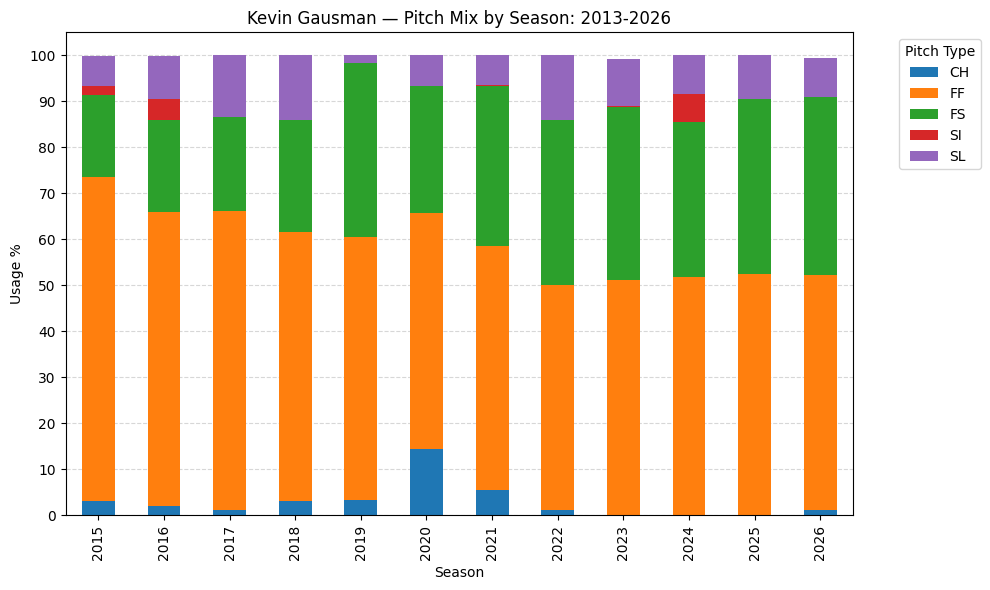

In [43]:
ax = pitch_mix_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
)

ax.set_title("Kevin Gausman — Pitch Mix by Season: 2013-2026")
ax.set_xlabel("Season")
ax.set_ylabel("Usage %")
ax.yaxis.set_major_locator(MultipleLocator(10))
ax.legend(title="Pitch Type", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

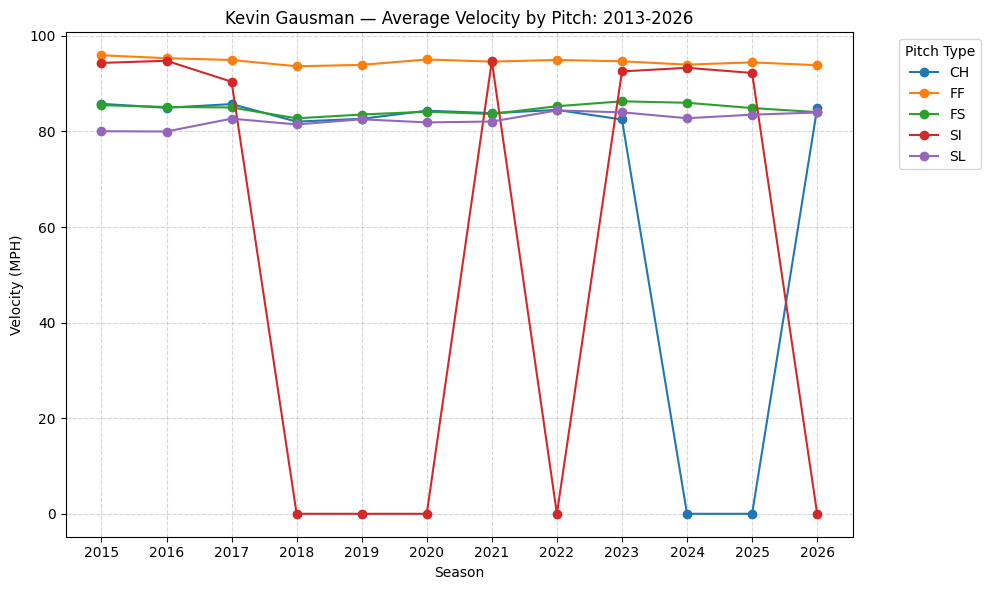

In [42]:
ax = avg_pitch_speeds.plot(
    kind='line',
    marker='o',
    figsize=(10, 6),
)

ax.set_title("Kevin Gausman — Average Velocity by Pitch: 2013-2026")
ax.set_xlabel("Season")
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.set_ylabel("Velocity (MPH)")
ax.legend(title="Pitch Type", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

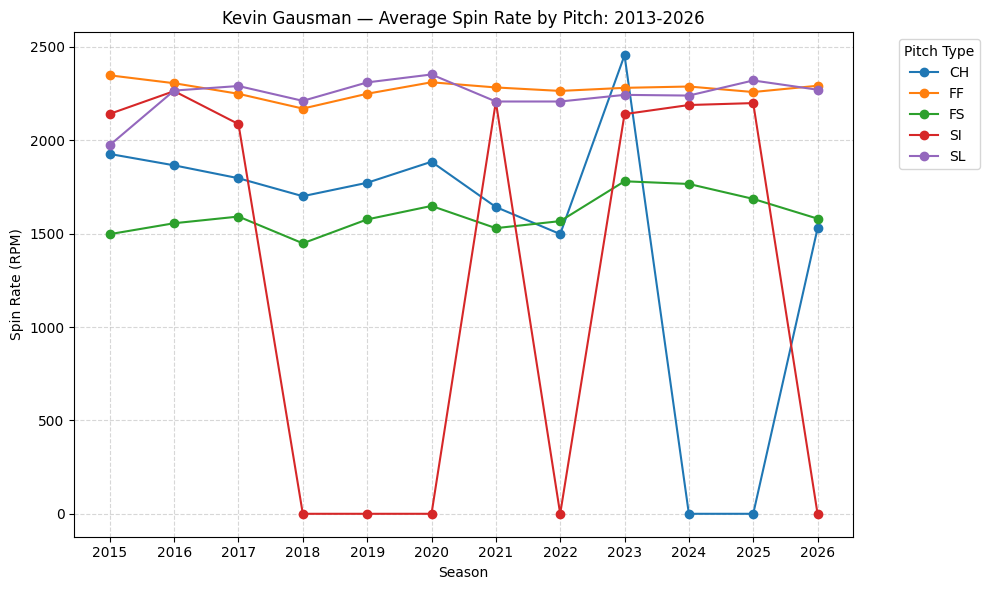

In [45]:
ax = avg_spin_rate.plot(
    kind='line',
    marker='o',
    figsize=(10, 6),
)

ax.set_title("Kevin Gausman — Average Spin Rate by Pitch: 2013-2026")
ax.set_xlabel("Season")
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.set_ylabel("Spin Rate (RPM)")
ax.legend(title="Pitch Type", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

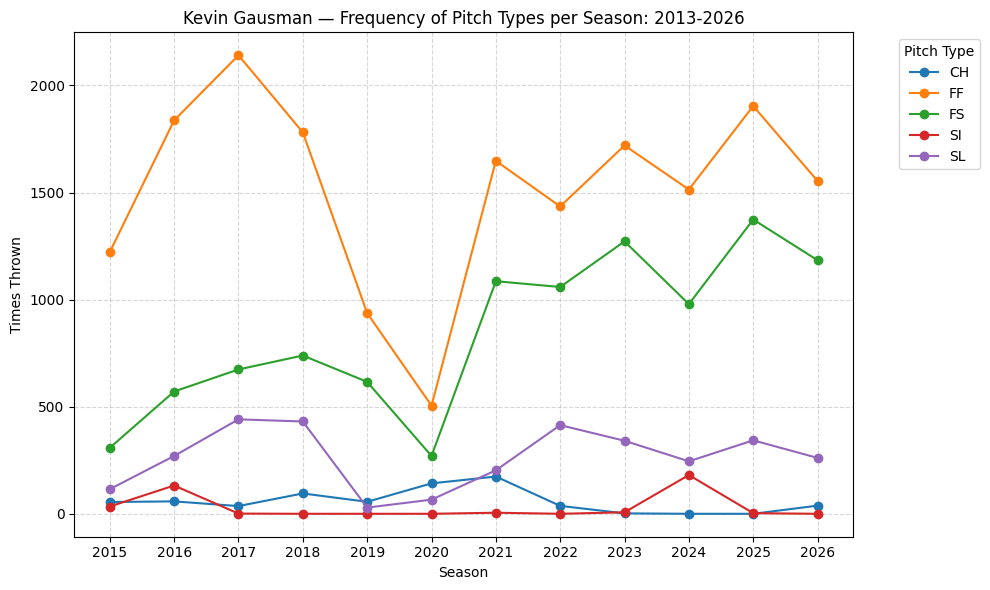

In [52]:
ax = num_pitches_per_type.plot(
    kind='line',
    marker='o',
    figsize=(10, 6),
)

ax.set_title("Kevin Gausman — Frequency of Pitch Types per Season: 2013-2026")
ax.set_xlabel("Season")
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.set_ylabel("Times Thrown")
ax.legend(title="Pitch Type", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()